In [ ]:
# 1. EMIT+MF
# 2. EMIT->S2 + MF
# 3. S2+MF
# 4. S2->EMIT + MF
# 5. Analysis

#### MF

In [ ]:
# 1. cd emit-utils
# 2. cd mag1c

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
import spectral
import xarray as xr
from netCDF4 import Dataset
from scipy.interpolate import interp1d

# import pvlib
import pandas as pd
import math
import datetime
import csv

#### 1. EMIT+MF

In [ ]:
rdn = "./res/case1/20240409T074435_emit_mf"  # √
rdn_file = spectral.io.envi.open(rdn + ".hdr")
rdn_file_memmap = rdn_file.open_memmap(interleave="bip", writable=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


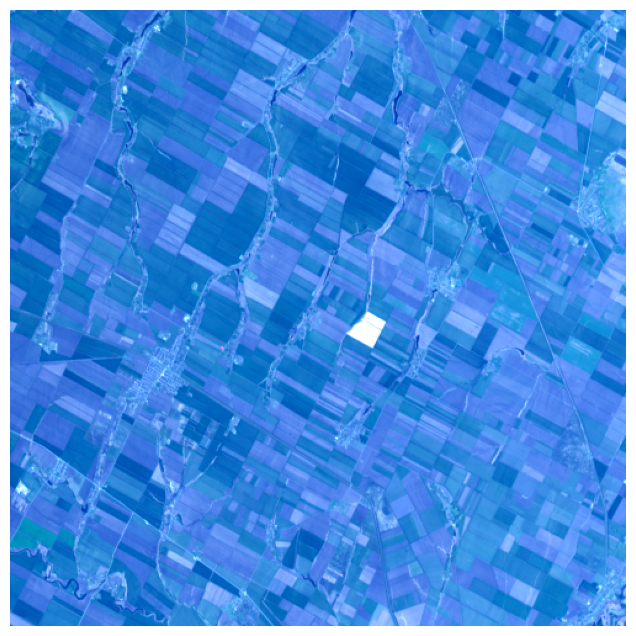

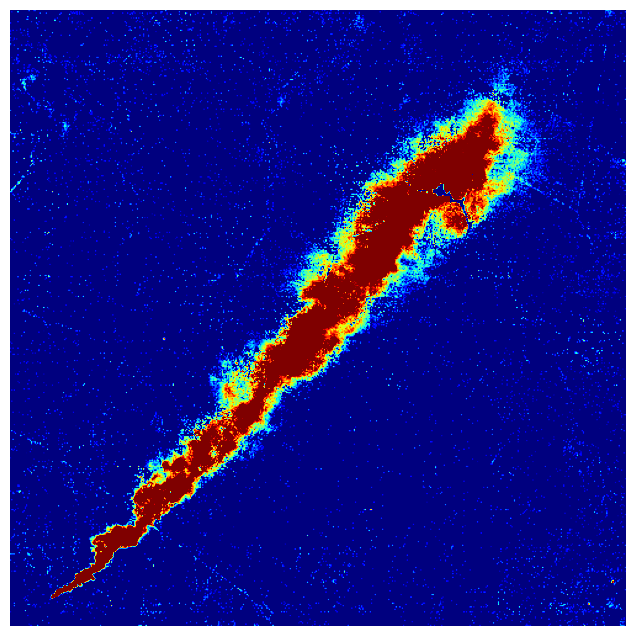

In [ ]:
# # data = np.array(rdn_file_memmap)
# data = np.rot90(rdn_file_memmap, k=1, axes=(0, 1))
# data = rotate(data, angle=30, reshape=True, order=3)
# # data = data[280:390, 351:461, :]
# # data = data[449:559, 372:482, :]
# # data = rdn_file_memmap
#   # shape: (height, width, bands)

data = rdn_file_memmap
rgb = data[:, :, 0:3][750:1250, 350:850, 0:3]  # [450:650, 550:750, 3]


def normalize(img):
    img_min = np.percentile(img, 2)
    img_max = np.percentile(img, 98)
    img_clipped = np.clip(img, img_min, img_max)
    return (img_clipped - img_min) / (img_max - img_min)


rgb_norm = normalize(rgb)

# center_x, center_y = 1250,700 #432, 489 # 411, 320
# center_x, center_y = 314,412
center_x, center_y = 650, 950
box_size = 600
top_left_x = center_x - box_size // 2
top_left_y = center_y - box_size // 2

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_norm)
rect = patches.Rectangle(
    (top_left_x, top_left_y),
    box_size,
    box_size,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)
ax.add_patch(rect)
# ax.set_title("RGB Composite with Red Box")
ax.axis("off")
plt.show()

# ppm = data[:, :, 3]
ppm = data[750:1250, 350:850, 3]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(ppm, cmap="jet", vmin=0, vmax=4000)
rect = patches.Rectangle(
    (top_left_x, top_left_y),
    box_size,
    box_size,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)
ax.add_patch(rect)
# plt.colorbar(im, ax=ax, label='Matched Filter Results (ppm m)')
# ax.set_title("PPM m Band with Red Box")
ax.axis("off")
plt.show()

### 2. S2 + Band Ratio

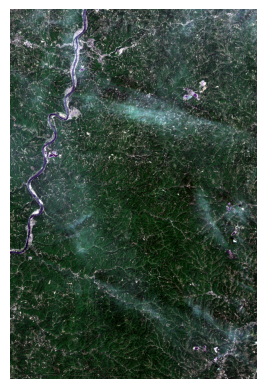

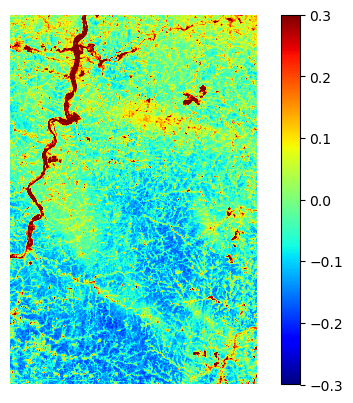

In [ ]:
def nor_img(channel_data):
    min_value = channel_data.min()
    max_value = channel_data.max()
    normalized_data = (channel_data - min_value) / (max_value - min_value)
    return normalized_data


def RGB_img(data):
    channel_data2 = nor_img(data[:, :, 3])
    channel_data3 = nor_img(data[:, :, 2])
    channel_data4 = nor_img(data[:, :, 1])
    channel_data = np.dstack((channel_data2, channel_data3, channel_data4))
    return channel_data


def stretch_percentile(band, pmin=2, pmax=99):
    lo, hi = np.percentile(band, (pmin, pmax))
    band = np.clip(band, lo, hi)
    return (band - lo) / (hi - lo + 1e-9)


def RGB_img_percentile(data, bands=(3, 2, 1), gamma=0.9):
    R = stretch_percentile(data[:, :, bands[0]])
    G = stretch_percentile(data[:, :, bands[1]])
    B = stretch_percentile(data[:, :, bands[2]])
    rgb = np.dstack((R, G, B)) ** gamma
    return np.clip(rgb, 0, 1)


def band_ratio_w_hm(data):
    band12 = data[:, :, 12]
    band11 = data[:, :, 11]

    out = np.full_like(band11, 1e-6, dtype=np.float32)
    eps = 1e-6
    valid = np.isfinite(band11) & np.isfinite(band12) & (band11 > eps) & (band12 > eps)

    c = band11.mean() / band12.mean()
    if band11.min() == 0:
        band11 += 1
    if band12.min() == 0:
        band12 += 1
    out[valid] = np.log(c * band12[valid] / band11[valid])
    return out
    # return np.log(c*band12/band11)


s2 = np.load("../generalized_dataset/s2/case5.npy")[
    :1500, :1000, :
]  # [200:500,400:1000,:]
# RGB_S2 = RGB_img(s2)
RGB_S2 = RGB_img_percentile(s2)
plt.imshow(RGB_S2)
plt.axis(False)
plt.show()
BR_S2 = band_ratio_w_hm(s2)
plt.imshow(BR_S2, cmap="jet", vmin=-0.3, vmax=0.3)
# plt.imshow(BR_S2[450:650, 550:750],vmin=-0.2, vmax=0.2)
plt.colorbar()
plt.axis(False)
plt.show()

### 3. S2 + MF

In [ ]:
from pathlib import Path


def write_envi_bsq(
    data, out_stem, wavelengths_nm=None, fwhm_nm=None, is_img=True, dtype=np.float32
):
    """
    data: (H, W, C) float
    out_stem: Path
    """
    H, W, C = data.shape
    if is_img:
        img_path = Path(out_stem).with_suffix(".img")
    else:
        img_path = Path(out_stem)
    hdr_path = Path(out_stem).with_suffix(".hdr")

    data = data.astype(dtype, copy=False)

    with open(img_path, "wb") as f:
        for c in range(C):
            data[:, :, c].tofile(f)

    def list_str(xs):
        return "{" + ", ".join(str(x) for x in xs) + "}"

    hdr = []
    hdr.append("ENVI")
    hdr.append(f"samples = {W}")
    hdr.append(f"lines   = {H}")
    hdr.append(f"bands   = {C}")
    hdr.append("header offset = 0")
    hdr.append("file type = ENVI Standard")
    hdr.append("data type = 4")  # 4=float32
    hdr.append("interleave = bsq")
    hdr.append("byte order = 0")
    if wavelengths_nm is not None:
        hdr.append("wavelength units = Nanometers")
        hdr.append("wavelength = " + list_str(wavelengths_nm))
    if fwhm_nm is not None:
        hdr.append("fwhm = " + list_str(fwhm_nm))

    Path(hdr_path).write_text("\n".join(hdr), encoding="utf-8")
    return str(img_path), str(hdr_path)

In [ ]:
s2 = np.load("../dataset/s2/2024-04-09T074435.npy")
s2 = s2.transpose((1, 2, 0))
# 0) 0-1
data = s2.astype(np.float32) / 10000.0

select_idx = [1, 2, 3, 4, 5, 6, 7, 8, 11, 12]
data = data[..., select_idx]

# H, W, C = data.shape
# X = data.reshape(-1, data.shape[-1])
# mu = np.nanmean(X, axis=0); std = np.nanstd(X, axis=0) + 1e-6
# Xn = (X - mu) / std
# Xn[~np.isfinite(Xn).any(axis=1)] = 0.0
# data_std = Xn.reshape(H, W, C)

out_stem = "./res/case1/20240409T074435_s2"

wavelengths_nm = [490, 560, 665, 704, 740, 783, 842, 865, 1610, 2190]
fwhm_nm = [65, 35, 30, 15, 15, 20, 115, 20, 90, 180]
write_envi_bsq(
    data,
    out_stem,
    wavelengths_nm=wavelengths_nm,
    fwhm_nm=fwhm_nm,
    is_img=True,
    dtype=np.float32,
)

('res/case1/20240409T074435_s2.img', 'res/case1/20240409T074435_s2.hdr')

In [ ]:
## Other case FROM S2!
from osgeo import gdal

ds = gdal.Open(
    "/mnt/d/Project3/generalization_data/Algeria/2019-11-18/aaf7db0ee84c3415c8be68b5bbd94096/response.tiff"
)
bands = ds.RasterCount
test = np.stack([ds.GetRasterBand(i + 1).ReadAsArray() for i in range(bands)], axis=-1)

test = test.astype(np.float32) / 10000.0

select_idx = [1, 2, 3, 4, 5, 6, 7, 8, 11, 12]
test = test[..., select_idx]

# H, W, C = test.shape
# X = test.reshape(-1, test.shape[-1])
# mu = np.nanmean(X, axis=0)
# std = np.nanstd(X, axis=0) + 1e-6
# Xn = (X - mu) / std
# Xn[~np.isfinite(Xn).any(axis=1)] = 0.0
# test_std = Xn.reshape(H, W, C)

out_stem = "./res/case1/test_s2"
wavelengths_nm = [490, 560, 665, 704, 740, 783, 842, 865, 1610, 2190]
fwhm_nm = [65, 35, 30, 15, 15, 20, 115, 20, 90, 180]
write_envi_bsq(
    test,
    out_stem,
    wavelengths_nm=wavelengths_nm,
    fwhm_nm=fwhm_nm,
    is_img=True,
    dtype=np.float32,
)

Warning 1: /mnt/d/Project3/generalization_data/Algeria/2019-11-18/aaf7db0ee84c3415c8be68b5bbd94096/response.tiff: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


('res/case1/test_s2.img', 'res/case1/test_s2.hdr')

In [ ]:
# MF

In [ ]:
rdn = "./res/case1/20240409T074435_s2_mf"  # √
rdn_file = spectral.io.envi.open(rdn + ".hdr")
rdn_file_memmap = rdn_file.open_memmap(interleave="bip", writable=False)

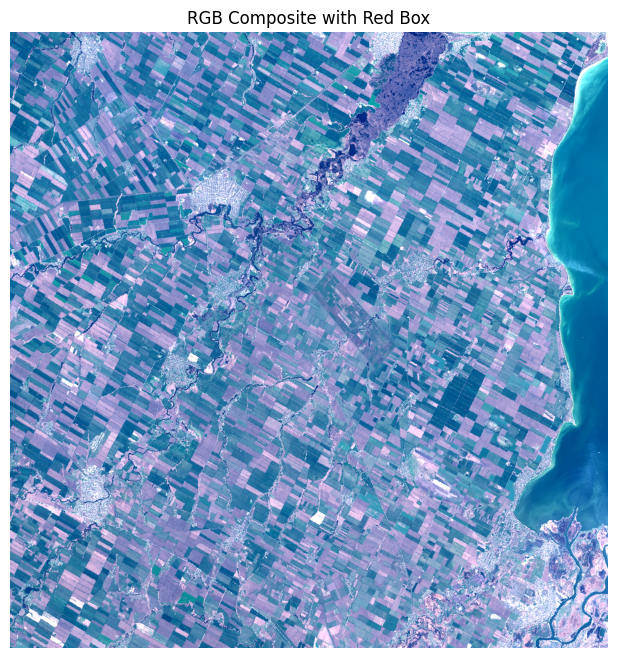

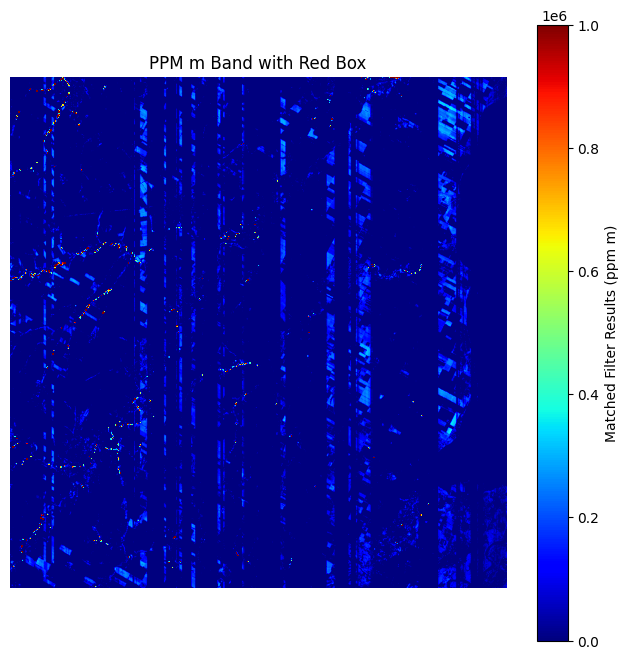

In [ ]:
data = rdn_file_memmap
rgb = data[:, :, 0:3]


def normalize(img):
    img_min = np.percentile(img, 2)
    img_max = np.percentile(img, 98)
    img_clipped = np.clip(img, img_min, img_max)
    return (img_clipped - img_min) / (img_max - img_min)


rgb_norm = normalize(rgb)

# center_x, center_y = 1250,700 #432, 489 # 411, 320
# center_x, center_y = 314,412
center_x, center_y = 1000, 1250
box_size = 600
top_left_x = center_x - box_size // 2
top_left_y = center_y - box_size // 2

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_norm)
rect = patches.Rectangle(
    (top_left_x, top_left_y),
    box_size,
    box_size,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)
# ax.add_patch(rect)
ax.set_title("RGB Composite with Red Box")
ax.axis("off")
plt.show()

ppm = data[:, :, 3]

fig, ax = plt.subplots(figsize=(8, 8))
# im = ax.imshow(ppm, cmap='jet')
im = ax.imshow(ppm, cmap="jet", vmin=0, vmax=1e6)
rect = patches.Rectangle(
    (top_left_x, top_left_y),
    box_size,
    box_size,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)
# ax.add_patch(rect)
plt.colorbar(im, ax=ax, label="Matched Filter Results (ppm m)")
ax.set_title("PPM m Band with Red Box")
ax.axis("off")
plt.show()

### 4. EMIT->S2 + MF

In [ ]:
# Band dilution validation
# emit_to_toa_and_synth.py


def earth_sun_distance_au(doy):
    # g = 2π (DOY - 1) / 365
    g = 2.0 * math.pi * (doy - 1) / 365.0
    d = (
        1.00011
        + 0.034221 * math.cos(g)
        + 0.001280 * math.sin(g)
        + 0.000719 * math.cos(2 * g)
        + 0.000077 * math.sin(2 * g)
    )
    return d


def radiance_to_toa_reflectance(L_lambda, E0_lambda, sza_deg, doy):
    # L_lambda: numpy array shape (bands, H, W) or (bands,) uW/cm^2/SR/nm
    # E0_lambda: array shape (bands,) in same wavelength grid as L_lambda  W/m²/um
    # sza_deg: solar zenith angle in degrees (scalar or per-pixel)
    sza_rad = np.deg2rad(sza_deg)
    d = earth_sun_distance_au(doy)
    print("distance:", d)
    # avoid divide by zero
    cos_sza = np.cos(sza_rad)
    # cos_sza = np.maximum(cos_sza, 1e-6)
    # print(cos_sza)
    # reflectance = pi * L * d^2 / (E0 * cos(SZA))
    rho = (math.pi * L_lambda * (d**2)) / (E0_lambda * cos_sza) * 1e5
    return rho

In [ ]:
import pvlib

loc = xr.open_dataset(
    "../EMIT_data/EMIT_L1B_RAD_001_20240409T074435_2410005_007.nc", group="location"
)
loc_lat = (loc.get("latitude") or loc.get("lat")).values
loc_lon = (loc.get("longitude") or loc.get("lon")).values

center_lat = float(np.nanmean(loc_lat))
center_lon = float(np.nanmean(loc_lon))
ts = pd.Timestamp("2024-04-09T07:44:35Z")
sp = pvlib.solarposition.get_solarposition(ts, center_lat, center_lon)
sza = float(sp["zenith"])
print("SZA =", sza, "degrees")

SZA = 44.4074705509344 degrees


/tmp/ipykernel_2113/3481234349.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sza = float(sp["zenith"])


In [ ]:
def build_S2_SRF_dict_nonzero(path_to_csv, srf_prefix="S2A_SR_AV_B"):

    df = pd.read_csv(path_to_csv)

    S2_SRF = {}

    band_cols = [c for c in df.columns if c.startswith(srf_prefix)]

    for col in band_cols:
        band_name = col.split("_")[-1]  # "B1"

        srf_raw = df[col].values.astype(np.float64)
        wl_raw = df["SR_WL"].values.astype(np.float64)

        mask = srf_raw > 0
        wl = wl_raw[mask]
        srf = srf_raw[mask]

        if len(wl) == 0:
            continue

        # srf = srf / (srf.sum() + 1e-12)
        srf = srf / srf.sum()

        S2_SRF[band_name] = {"wvl": wl, "srf": srf}

    return S2_SRF

In [ ]:
##############################################
# 1. Sentinel-2 Spectral Response Function (SRF)
##############################################
S2_SRF = build_S2_SRF_dict_nonzero("./Project4/dataset/spectral_responses_S2A.csv")

In [ ]:
###################################################
# 2. From EMIT L1B NetCDF Load radiance + wavelength
###################################################

emit_file = "../EMIT_data/EMIT_L1B_RAD_001_20240409T074435_2410005_007.nc"

ds = xr.open_dataset(emit_file)
emit_rdn = ds["radiance"].values.transpose((2, 0, 1))  # shape = (bands, rows, cols)
# emit_wvl = ds["wavelength"][:]       # shape = (bands,)
emit_wvl = [
    381.00558,
    388.4092,
    395.81583,
    403.2254,
    410.638,
    418.0536,
    425.47214,
    432.8927,
    440.31726,
    447.7428,
    455.17035,
    462.59888,
    470.0304,
    477.46292,
    484.89743,
    492.33292,
    499.77142,
    507.2099,
    514.6504,
    522.0909,
    529.5333,
    536.9768,
    544.42126,
    551.8667,
    559.3142,
    566.7616,
    574.20905,
    581.6585,
    589.108,
    596.55835,
    604.0098,
    611.4622,
    618.9146,
    626.36804,
    633.8215,
    641.2759,
    648.7303,
    656.1857,
    663.6411,
    671.09753,
    678.5539,
    686.0103,
    693.4677,
    700.9251,
    708.38354,
    715.84094,
    723.2993,
    730.7587,
    738.2171,
    745.6765,
    753.1359,
    760.5963,
    768.0557,
    775.5161,
    782.97754,
    790.4379,
    797.89935,
    805.36176,
    812.8232,
    820.2846,
    827.746,
    835.2074,
    842.66986,
    850.1313,
    857.5937,
    865.0551,
    872.5176,
    879.98004,
    887.44147,
    894.90393,
    902.3664,
    909.82886,
    917.2913,
    924.7538,
    932.21625,
    939.6788,
    947.14026,
    954.6027,
    962.0643,
    969.5268,
    976.9883,
    984.4498,
    991.9114,
    999.37286,
    1006.8344,
    1014.295,
    1021.7566,
    1029.2172,
    1036.6777,
    1044.1383,
    1051.5989,
    1059.0596,
    1066.5201,
    1073.9797,
    1081.4404,
    1088.9,
    1096.3597,
    1103.8184,
    1111.2781,
    1118.7368,
    1126.1964,
    1133.6552,
    1141.1129,
    1148.5717,
    1156.0304,
    1163.4882,
    1170.9459,
    1178.4037,
    1185.8616,
    1193.3184,
    1200.7761,
    1208.233,
    1215.6898,
    1223.1467,
    1230.6036,
    1238.0596,
    1245.5154,
    1252.9724,
    1260.4283,
    1267.8833,
    1275.3392,
    1282.7942,
    1290.2502,
    1297.7052,
    1305.1603,
    1312.6144,
    1320.0685,
    1327.5225,
    1334.9756,
    1342.4287,
    1349.8818,
    1357.3351,
    1364.7872,
    1372.2384,
    1379.6907,
    1387.1418,
    1394.5931,
    1402.0433,
    1409.4937,
    1416.944,
    1424.3933,
    1431.8427,
    1439.292,
    1446.7404,
    1454.1888,
    1461.6372,
    1469.0847,
    1476.5321,
    1483.9796,
    1491.4261,
    1498.8727,
    1506.3192,
    1513.7649,
    1521.2104,
    1528.655,
    1536.1007,
    1543.5454,
    1550.9891,
    1558.4329,
    1565.8766,
    1573.3193,
    1580.7621,
    1588.205,
    1595.6467,
    1603.0886,
    1610.5295,
    1617.9705,
    1625.4104,
    1632.8513,
    1640.2903,
    1647.7303,
    1655.1694,
    1662.6074,
    1670.0455,
    1677.4836,
    1684.9209,
    1692.358,
    1699.7952,
    1707.2314,
    1714.6667,
    1722.103,
    1729.5383,
    1736.9727,
    1744.4071,
    1751.8414,
    1759.2749,
    1766.7084,
    1774.1418,
    1781.5743,
    1789.007,
    1796.4385,
    1803.8701,
    1811.3008,
    1818.7314,
    1826.1611,
    1833.591,
    1841.0206,
    1848.4495,
    1855.8773,
    1863.3052,
    1870.733,
    1878.16,
    1885.5869,
    1893.013,
    1900.439,
    1907.864,
    1915.2892,
    1922.7133,
    1930.1375,
    1937.5607,
    1944.9839,
    1952.4071,
    1959.8295,
    1967.2518,
    1974.6732,
    1982.0946,
    1989.515,
    1996.9355,
    2004.355,
    2011.7745,
    2019.1931,
    2026.6118,
    2034.0304,
    2041.4471,
    2048.865,
    2056.2808,
    2063.6965,
    2071.1123,
    2078.5273,
    2085.9421,
    2093.3562,
    2100.769,
    2108.1821,
    2115.5942,
    2123.0063,
    2130.4175,
    2137.8289,
    2145.239,
    2152.6482,
    2160.0576,
    2167.467,
    2174.8755,
    2182.283,
    2189.6904,
    2197.097,
    2204.5034,
    2211.9092,
    2219.3147,
    2226.7195,
    2234.1233,
    2241.5269,
    2248.9297,
    2256.3328,
    2263.7346,
    2271.1365,
    2278.5376,
    2285.9387,
    2293.3386,
    2300.7378,
    2308.136,
    2315.5342,
    2322.9326,
    2330.3298,
    2337.7263,
    2345.1216,
    2352.517,
    2359.9126,
    2367.3071,
    2374.7007,
    2382.0935,
    2389.486,
    2396.878,
    2404.2695,
    2411.6604,
    2419.0513,
    2426.4402,
    2433.8303,
    2441.2183,
    2448.6064,
    2455.9944,
    2463.3816,
    2470.7678,
    2478.153,
    2485.5386,
    2492.9238,
]
ds.close()

# emit_rdn = emit_rdn.data
emit_wvl = np.array(emit_wvl)
print("EMIT radiance shape:", emit_rdn.shape)
print("EMIT wavelength shape:", emit_wvl.shape)

EMIT radiance shape: (285, 1280, 1242)
EMIT wavelength shape: (285,)


In [ ]:
input_path = "./Project4/dataset/TOA_spectral_irradiance.txt"
output_path = "./Project4/dataset/toa_solar_spectrum_thuillier_380_2400nm_S2units.csv"

rows = []
in_data = False

with open(input_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        if line.lower().startswith("/end_header"):
            in_data = True
            continue

        if not in_data:
            continue

        parts = line.split()
        if len(parts) < 2:
            continue

        try:
            wl_nm = float(parts[0])
            F_uW_cm2_nm = float(parts[1])
        except ValueError:
            continue

        if wl_nm < 380.0:
            continue

        # W/m^2/µm
        F_W_m2_um = F_uW_cm2_nm * 10.0

        rows.append((wl_nm, F_W_m2_um))

with open(output_path, "w", newline="") as f_out:
    writer = csv.writer(f_out)
    writer.writerow(["wavelength_nm", "irradiance_W_m2_um"])
    writer.writerows(rows)

print(f"Saved {len(rows)} rows to {output_path}")

Saved 2018 rows to /mnt/d/Project4/dataset/toa_solar_spectrum_thuillier_380_2400nm_S2units.csv


In [ ]:
###################################################
# 3. TOA radiance-> TOA Reflectance-DN
###################################################
df_solar = pd.read_csv(
    "/mnt/d/Project4/dataset/toa_solar_spectrum_thuillier_380_2400nm_S2units.csv"
)
solar_wvl = df_solar["wavelength_nm"].to_numpy()  # nm
solar_E0 = df_solar["irradiance_W_m2_um"].to_numpy()  # W/m²/um
E0_real = np.interp(emit_wvl, solar_wvl, solar_E0)  # [bands]

L = np.asarray(emit_rdn, dtype=np.float32)  # (bands, H, W)
E0_shaped = E0_real.astype(np.float32)
E0_arr = np.asarray(E0_shaped[:, None, None], dtype=np.float32)

doy = datetime.datetime(2024, 4, 9).timetuple().tm_yday
rho_toa = radiance_to_toa_reflectance(
    L, E0_arr, sza, doy
)  # rho_toa now approx TOA reflectance on emit_wvl grid

distance: 0.9961128698943429


In [ ]:
###################################################
# 4. Construct spectral interpolation function (EMIT -> SRF wavelength)
###################################################

interp_func = interp1d(
    emit_wvl, rho_toa, axis=0, bounds_error=False, fill_value="extrapolate"
)

In [ ]:
###################################################
# 5. SRF weighted integration to generate Sentinel-2 synthetic data
###################################################

band_list = list(S2_SRF.keys())
S2_synth = {}

for band in band_list:
    s2_wvl = S2_SRF[band]["wvl"]
    s2_resp = S2_SRF[band]["srf"]

    emit_interp = interp_func(s2_wvl)  # shape = (3, rows, cols)

    weighted = np.sum(emit_interp * s2_resp[:, None, None], axis=0)
    norm = np.sum(s2_resp)

    S2_synth[band] = weighted / norm  # shape = (rows, cols)

In [ ]:
# Band dilution validation

###################################################
# Output
###################################################

bands_sorted = [
    "B1",
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B9",
    "B10",
    "B11",
    "B12",
]

S2_cube = np.stack([S2_synth[b] for b in bands_sorted], axis=0)
S2_cube = S2_cube.transpose((1, 2, 0))
print("S2_synth shape =", S2_cube.shape)
# -> (13, rows, cols)

###################################################
# Save
###################################################
np.save("./res/case1/20240409T074435_s2_syn.npy", S2_cube)
print("Saved to S2_synth_from_EMIT.npy")

S2_synth shape = (1280, 1242, 13)
Saved to S2_synth_from_EMIT.npy


In [ ]:
S2_cube.mean(axis=(0, 1)), S2_cube.std(axis=(0, 1))

(array([1248.27080761, 1018.5319577 ,  876.87166098,  745.64376229,
         887.62626242, 1646.88774803, 1973.68518764, 1952.76075908,
        2054.20894986,  877.3255661 ,   15.1355165 , 1651.77627937,
        1121.00557095]),
 array([ 70.90617336,  95.03279334, 106.92175734, 220.75739158,
        206.72591172, 673.6601593 , 949.18451075, 934.66271054,
        982.01428663, 395.08331686,   2.44390891, 576.38022102,
        549.01112715]))

In [16]:
d = dict(np.load("./SSR/s2_stats_robust.npz"))
d

{'p2': array([1097.5579   ,  816.5659   ,  634.06305  ,  418.6431   ,
         476.89935  ,  420.39935  ,  414.94153  ,  347.8685   ,
         364.4605   ,  103.05753  ,    6.6346273,  210.91466  ,
         154.40282  ], dtype=float32),
 'p98': array([2562.2266 , 2740.2922 , 3258.711  , 4690.6333 , 4918.226  ,
        5237.1577 , 5574.2676 , 5321.7373 , 5727.324  , 2467.9307 ,
         162.62805, 6645.6724 , 5812.808  ], dtype=float32),
 'mean': array([1753.2766  , 1663.0367  , 1815.5573  , 2292.6604  , 2440.2551  ,
        2766.1858  , 3007.9905  , 2904.3972  , 3172.4526  , 1107.3     ,
          26.508743, 3426.6846  , 2788.711   ], dtype=float32),
 'std': array([ 632.4201  ,  703.50696 ,  818.14954 , 1229.0431  , 1228.9967  ,
        1191.7975  , 1248.6794  , 1189.3175  , 1263.5217  ,  552.93945 ,
          34.656853, 1615.2585  , 1473.9866  ], dtype=float32)}

In [38]:
s2 = np.load("../dataset/s2/2024-04-09T074435.npy")
S2_cube = np.load("./res/case1/20240409T074435_s2_syn.npy")
# s2 = s2.transpose((1,2,0))

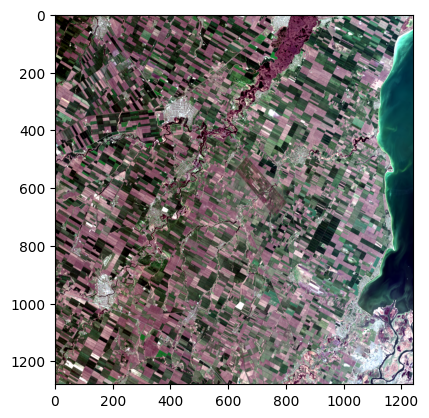

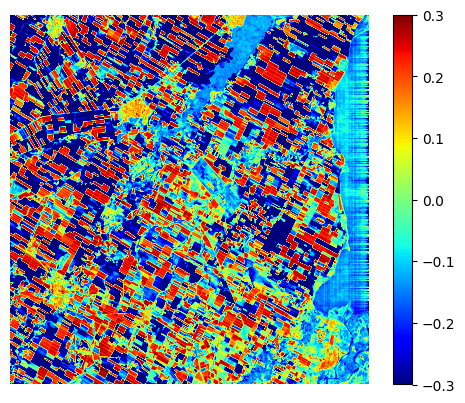

In [41]:
RGB_S2_cube = RGB_img_percentile(S2_cube)
plt.imshow(RGB_S2_cube)
plt.show()
BR_S2_cube = band_ratio_w_hm(S2_cube)
plt.imshow(BR_S2_cube, cmap="jet", vmin=-0.3, vmax=0.3)
# plt.imshow(BR_S2[450:650, 550:750],vmin=-0.2, vmax=0.2)
plt.colorbar()
plt.axis("off")
plt.show()

In [16]:
# rho_toa.shape, emit_rdn.shape, S2_cube.shape, s2.shape
np.mean((rho_toa - emit_rdn) ** 2), np.mean(
    (S2_cube - s2) ** 2
), S2_cube.shape, s2.shape

(1933195.1, 27496.603600143644, (1280, 1242, 13), (1280, 1242, 13))

In [19]:
S2_cube[:, :, 12], s2[:, :, 12], ds["radiance"].attrs["units"]

(array([[ 476.4873612 ,  572.76042771,  587.34809052, ..., 1828.91079088,
          173.05709543,   66.02124024],
        [ 483.36850967,  540.78412167,  534.79303934, ..., 1629.13991763,
          105.33378787,   29.91942966],
        [ 476.96500565,  498.23751899,  477.07570372, ..., 1396.48780933,
           67.75828427,   10.67416347],
        ...,
        [ 535.43567637,  833.74599051, 1383.93366182, ..., 1419.70511627,
         1483.11524276, 1589.91970756],
        [ 535.78867204,  509.29226372,  573.861724  , ..., 1486.48328063,
         1500.66900881, 1563.10940217],
        [ 470.7027932 ,  517.98796213,  518.13125937, ..., 1535.36087052,
         1513.00110389, 1576.12288131]]),
 array([[ 851.48364,  607.87274,  772.4677 , ..., 1829.2325 ,   36.61959,
          128.13959],
        [ 585.4844 ,  732.46906,  780.27606, ..., 2231.0654 ,  -78.03832,
          -78.03832],
        [ 535.23486,  629.923  ,  634.15234, ..., 2281.6853 , -164.53358,
          151.87038],
        ...,


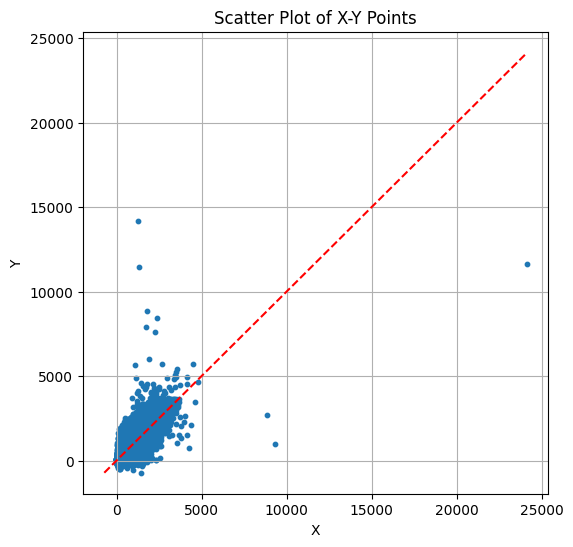

In [ ]:
plt.figure(figsize=(6, 6))
x, y = S2_cube[:, :, 12].reshape(-1), s2[:, :, 12].reshape(-1)
plt.scatter(x, y, s=10)

min_val = min(min(x), min(y))
max_val = max(max(x), max(y))
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="x = y")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter Plot of X-Y Points")
plt.grid(True)
plt.show()

### 5. S2->EMIT + MF

In [ ]:
s2_emit = np.load("./res/case1/2024-04-09T074435_pred_AWAN.npy")
out_stem = "./res/case1/20240409T074435_s2_emit_AWAN"

wavelengths_nm = [
    381.00558,
    388.4092,
    395.81583,
    403.2254,
    410.638,
    418.0536,
    425.47214,
    432.8927,
    440.31726,
    447.7428,
    455.17035,
    462.59888,
    470.0304,
    477.46292,
    484.89743,
    492.33292,
    499.77142,
    507.2099,
    514.6504,
    522.0909,
    529.5333,
    536.9768,
    544.42126,
    551.8667,
    559.3142,
    566.7616,
    574.20905,
    581.6585,
    589.108,
    596.55835,
    604.0098,
    611.4622,
    618.9146,
    626.36804,
    633.8215,
    641.2759,
    648.7303,
    656.1857,
    663.6411,
    671.09753,
    678.5539,
    686.0103,
    693.4677,
    700.9251,
    708.38354,
    715.84094,
    723.2993,
    730.7587,
    738.2171,
    745.6765,
    753.1359,
    760.5963,
    768.0557,
    775.5161,
    782.97754,
    790.4379,
    797.89935,
    805.36176,
    812.8232,
    820.2846,
    827.746,
    835.2074,
    842.66986,
    850.1313,
    857.5937,
    865.0551,
    872.5176,
    879.98004,
    887.44147,
    894.90393,
    902.3664,
    909.82886,
    917.2913,
    924.7538,
    932.21625,
    939.6788,
    947.14026,
    954.6027,
    962.0643,
    969.5268,
    976.9883,
    984.4498,
    991.9114,
    999.37286,
    1006.8344,
    1014.295,
    1021.7566,
    1029.2172,
    1036.6777,
    1044.1383,
    1051.5989,
    1059.0596,
    1066.5201,
    1073.9797,
    1081.4404,
    1088.9,
    1096.3597,
    1103.8184,
    1111.2781,
    1118.7368,
    1126.1964,
    1133.6552,
    1141.1129,
    1148.5717,
    1156.0304,
    1163.4882,
    1170.9459,
    1178.4037,
    1185.8616,
    1193.3184,
    1200.7761,
    1208.233,
    1215.6898,
    1223.1467,
    1230.6036,
    1238.0596,
    1245.5154,
    1252.9724,
    1260.4283,
    1267.8833,
    1275.3392,
    1282.7942,
    1290.2502,
    1297.7052,
    1305.1603,
    1312.6144,
    1320.0685,
    1327.5225,
    1334.9756,
    1342.4287,
    1349.8818,
    1357.3351,
    1364.7872,
    1372.2384,
    1379.6907,
    1387.1418,
    1394.5931,
    1402.0433,
    1409.4937,
    1416.944,
    1424.3933,
    1431.8427,
    1439.292,
    1446.7404,
    1454.1888,
    1461.6372,
    1469.0847,
    1476.5321,
    1483.9796,
    1491.4261,
    1498.8727,
    1506.3192,
    1513.7649,
    1521.2104,
    1528.655,
    1536.1007,
    1543.5454,
    1550.9891,
    1558.4329,
    1565.8766,
    1573.3193,
    1580.7621,
    1588.205,
    1595.6467,
    1603.0886,
    1610.5295,
    1617.9705,
    1625.4104,
    1632.8513,
    1640.2903,
    1647.7303,
    1655.1694,
    1662.6074,
    1670.0455,
    1677.4836,
    1684.9209,
    1692.358,
    1699.7952,
    1707.2314,
    1714.6667,
    1722.103,
    1729.5383,
    1736.9727,
    1744.4071,
    1751.8414,
    1759.2749,
    1766.7084,
    1774.1418,
    1781.5743,
    1789.007,
    1796.4385,
    1803.8701,
    1811.3008,
    1818.7314,
    1826.1611,
    1833.591,
    1841.0206,
    1848.4495,
    1855.8773,
    1863.3052,
    1870.733,
    1878.16,
    1885.5869,
    1893.013,
    1900.439,
    1907.864,
    1915.2892,
    1922.7133,
    1930.1375,
    1937.5607,
    1944.9839,
    1952.4071,
    1959.8295,
    1967.2518,
    1974.6732,
    1982.0946,
    1989.515,
    1996.9355,
    2004.355,
    2011.7745,
    2019.1931,
    2026.6118,
    2034.0304,
    2041.4471,
    2048.865,
    2056.2808,
    2063.6965,
    2071.1123,
    2078.5273,
    2085.9421,
    2093.3562,
    2100.769,
    2108.1821,
    2115.5942,
    2123.0063,
    2130.4175,
    2137.8289,
    2145.239,
    2152.6482,
    2160.0576,
    2167.467,
    2174.8755,
    2182.283,
    2189.6904,
    2197.097,
    2204.5034,
    2211.9092,
    2219.3147,
    2226.7195,
    2234.1233,
    2241.5269,
    2248.9297,
    2256.3328,
    2263.7346,
    2271.1365,
    2278.5376,
    2285.9387,
    2293.3386,
    2300.7378,
    2308.136,
    2315.5342,
    2322.9326,
    2330.3298,
    2337.7263,
    2345.1216,
    2352.517,
    2359.9126,
    2367.3071,
    2374.7007,
    2382.0935,
    2389.486,
    2396.878,
    2404.2695,
    2411.6604,
    2419.0513,
    2426.4402,
    2433.8303,
    2441.2183,
    2448.6064,
    2455.9944,
    2463.3816,
    2470.7678,
    2478.153,
    2485.5386,
    2492.9238,
]
fwhm_nm = [
    8.415,
    8.415,
    8.415,
    8.415,
    8.417,
    8.418,
    8.419,
    8.421,
    8.422,
    8.424,
    8.425,
    8.426,
    8.428,
    8.429,
    8.431,
    8.432,
    8.433,
    8.435,
    8.436,
    8.438,
    8.439,
    8.44,
    8.442,
    8.443,
    8.445,
    8.446,
    8.447,
    8.449,
    8.45,
    8.452,
    8.453,
    8.454,
    8.456,
    8.457,
    8.459,
    8.46,
    8.461,
    8.463,
    8.464,
    8.466,
    8.467,
    8.468,
    8.47,
    8.471,
    8.473,
    8.474,
    8.475,
    8.477,
    8.478,
    8.48,
    8.481,
    8.482,
    8.484,
    8.485,
    8.487,
    8.488,
    8.489,
    8.491,
    8.492,
    8.494,
    8.495,
    8.496,
    8.498,
    8.499,
    8.501,
    8.502,
    8.503,
    8.505,
    8.506,
    8.508,
    8.509,
    8.51,
    8.512,
    8.513,
    8.515,
    8.516,
    8.517,
    8.519,
    8.52,
    8.522,
    8.523,
    8.524,
    8.526,
    8.527,
    8.529,
    8.53,
    8.531,
    8.533,
    8.534,
    8.536,
    8.537,
    8.538,
    8.54,
    8.541,
    8.543,
    8.544,
    8.545,
    8.547,
    8.548,
    8.55,
    8.551,
    8.552,
    8.554,
    8.555,
    8.557,
    8.558,
    8.559,
    8.561,
    8.562,
    8.564,
    8.565,
    8.566,
    8.568,
    8.569,
    8.571,
    8.572,
    8.573,
    8.575,
    8.576,
    8.578,
    8.579,
    8.58,
    8.582,
    8.583,
    8.585,
    8.586,
    8.587,
    8.589,
    8.59,
    8.592,
    8.593,
    8.594,
    8.596,
    8.597,
    8.599,
    8.6,
    8.601,
    8.603,
    8.604,
    8.606,
    8.607,
    8.608,
    8.61,
    8.611,
    8.613,
    8.614,
    8.615,
    8.617,
    8.618,
    8.62,
    8.621,
    8.622,
    8.624,
    8.625,
    8.627,
    8.628,
    8.629,
    8.631,
    8.632,
    8.634,
    8.635,
    8.636,
    8.638,
    8.639,
    8.641,
    8.642,
    8.643,
    8.645,
    8.646,
    8.648,
    8.649,
    8.65,
    8.652,
    8.653,
    8.655,
    8.656,
    8.657,
    8.659,
    8.66,
    8.662,
    8.663,
    8.664,
    8.666,
    8.667,
    8.669,
    8.67,
    8.671,
    8.673,
    8.674,
    8.676,
    8.677,
    8.678,
    8.68,
    8.681,
    8.683,
    8.684,
    8.685,
    8.687,
    8.688,
    8.69,
    8.691,
    8.692,
    8.694,
    8.695,
    8.697,
    8.698,
    8.699,
    8.701,
    8.702,
    8.704,
    8.705,
    8.706,
    8.708,
    8.709,
    8.711,
    8.712,
    8.714,
    8.715,
    8.716,
    8.718,
    8.719,
    8.721,
    8.722,
    8.723,
    8.725,
    8.726,
    8.727,
    8.729,
    8.73,
    8.732,
    8.733,
    8.734,
    8.736,
    8.737,
    8.739,
    8.74,
    8.741,
    8.743,
    8.744,
    8.746,
    8.747,
    8.748,
    8.75,
    8.751,
    8.753,
    8.754,
    8.755,
    8.757,
    8.758,
    8.76,
    8.761,
    8.763,
    8.764,
    8.765,
    8.767,
    8.768,
    8.77,
    8.771,
    8.772,
    8.774,
    8.775,
    8.777,
    8.778,
    8.779,
    8.781,
    8.782,
    8.783,
    8.785,
    8.786,
    8.788,
    8.789,
    8.79,
    8.792,
    8.793,
    8.795,
    8.796,
    8.797,
    8.799,
    8.8,
    8.802,
    8.803,
    8.804,
    8.806,
    8.807,
    8.809,
]

# band_std = np.nanstd(s2_emit, axis=(0, 1))
# valid_bands = band_std > 1e-6

# s2_emit_valid = s2_emit[..., valid_bands]
# wl_valid = np.array(wavelengths_nm)[valid_bands]
# fwhm_valid = np.array(fwhm_nm)[valid_bands]

# write_envi_bsq(s2_emit, out_stem, wavelengths_nm=wavelengths_nm, fwhm_nm=fwhm_nm, is_img=False, dtype=np.float32)
write_envi_bsq(
    s2_emit,
    out_stem,
    wavelengths_nm=wavelengths_nm[-60:],
    fwhm_nm=fwhm_nm[-60:],
    is_img=False,
    dtype=np.float32,
)

('res/case1/20240409T074435_s2_emit_AWAN',
 'res/case1/20240409T074435_s2_emit_AWAN.hdr')

In [ ]:
### EMIT Format
import netCDF4

# from netCDF4 import Dataset
wavelengths_nm = [
    381.00558,
    388.4092,
    395.81583,
    403.2254,
    410.638,
    418.0536,
    425.47214,
    432.8927,
    440.31726,
    447.7428,
    455.17035,
    462.59888,
    470.0304,
    477.46292,
    484.89743,
    492.33292,
    499.77142,
    507.2099,
    514.6504,
    522.0909,
    529.5333,
    536.9768,
    544.42126,
    551.8667,
    559.3142,
    566.7616,
    574.20905,
    581.6585,
    589.108,
    596.55835,
    604.0098,
    611.4622,
    618.9146,
    626.36804,
    633.8215,
    641.2759,
    648.7303,
    656.1857,
    663.6411,
    671.09753,
    678.5539,
    686.0103,
    693.4677,
    700.9251,
    708.38354,
    715.84094,
    723.2993,
    730.7587,
    738.2171,
    745.6765,
    753.1359,
    760.5963,
    768.0557,
    775.5161,
    782.97754,
    790.4379,
    797.89935,
    805.36176,
    812.8232,
    820.2846,
    827.746,
    835.2074,
    842.66986,
    850.1313,
    857.5937,
    865.0551,
    872.5176,
    879.98004,
    887.44147,
    894.90393,
    902.3664,
    909.82886,
    917.2913,
    924.7538,
    932.21625,
    939.6788,
    947.14026,
    954.6027,
    962.0643,
    969.5268,
    976.9883,
    984.4498,
    991.9114,
    999.37286,
    1006.8344,
    1014.295,
    1021.7566,
    1029.2172,
    1036.6777,
    1044.1383,
    1051.5989,
    1059.0596,
    1066.5201,
    1073.9797,
    1081.4404,
    1088.9,
    1096.3597,
    1103.8184,
    1111.2781,
    1118.7368,
    1126.1964,
    1133.6552,
    1141.1129,
    1148.5717,
    1156.0304,
    1163.4882,
    1170.9459,
    1178.4037,
    1185.8616,
    1193.3184,
    1200.7761,
    1208.233,
    1215.6898,
    1223.1467,
    1230.6036,
    1238.0596,
    1245.5154,
    1252.9724,
    1260.4283,
    1267.8833,
    1275.3392,
    1282.7942,
    1290.2502,
    1297.7052,
    1305.1603,
    1312.6144,
    1320.0685,
    1327.5225,
    1334.9756,
    1342.4287,
    1349.8818,
    1357.3351,
    1364.7872,
    1372.2384,
    1379.6907,
    1387.1418,
    1394.5931,
    1402.0433,
    1409.4937,
    1416.944,
    1424.3933,
    1431.8427,
    1439.292,
    1446.7404,
    1454.1888,
    1461.6372,
    1469.0847,
    1476.5321,
    1483.9796,
    1491.4261,
    1498.8727,
    1506.3192,
    1513.7649,
    1521.2104,
    1528.655,
    1536.1007,
    1543.5454,
    1550.9891,
    1558.4329,
    1565.8766,
    1573.3193,
    1580.7621,
    1588.205,
    1595.6467,
    1603.0886,
    1610.5295,
    1617.9705,
    1625.4104,
    1632.8513,
    1640.2903,
    1647.7303,
    1655.1694,
    1662.6074,
    1670.0455,
    1677.4836,
    1684.9209,
    1692.358,
    1699.7952,
    1707.2314,
    1714.6667,
    1722.103,
    1729.5383,
    1736.9727,
    1744.4071,
    1751.8414,
    1759.2749,
    1766.7084,
    1774.1418,
    1781.5743,
    1789.007,
    1796.4385,
    1803.8701,
    1811.3008,
    1818.7314,
    1826.1611,
    1833.591,
    1841.0206,
    1848.4495,
    1855.8773,
    1863.3052,
    1870.733,
    1878.16,
    1885.5869,
    1893.013,
    1900.439,
    1907.864,
    1915.2892,
    1922.7133,
    1930.1375,
    1937.5607,
    1944.9839,
    1952.4071,
    1959.8295,
    1967.2518,
    1974.6732,
    1982.0946,
    1989.515,
    1996.9355,
    2004.355,
    2011.7745,
    2019.1931,
    2026.6118,
    2034.0304,
    2041.4471,
    2048.865,
    2056.2808,
    2063.6965,
    2071.1123,
    2078.5273,
    2085.9421,
    2093.3562,
    2100.769,
    2108.1821,
    2115.5942,
    2123.0063,
    2130.4175,
    2137.8289,
    2145.239,
    2152.6482,
    2160.0576,
    2167.467,
    2174.8755,
    2182.283,
    2189.6904,
    2197.097,
    2204.5034,
    2211.9092,
    2219.3147,
    2226.7195,
    2234.1233,
    2241.5269,
    2248.9297,
    2256.3328,
    2263.7346,
    2271.1365,
    2278.5376,
    2285.9387,
    2293.3386,
    2300.7378,
    2308.136,
    2315.5342,
    2322.9326,
    2330.3298,
    2337.7263,
    2345.1216,
    2352.517,
    2359.9126,
    2367.3071,
    2374.7007,
    2382.0935,
    2389.486,
    2396.878,
    2404.2695,
    2411.6604,
    2419.0513,
    2426.4402,
    2433.8303,
    2441.2183,
    2448.6064,
    2455.9944,
    2463.3816,
    2470.7678,
    2478.153,
    2485.5386,
    2492.9238,
]
fwhm_nm = [
    8.415,
    8.415,
    8.415,
    8.415,
    8.417,
    8.418,
    8.419,
    8.421,
    8.422,
    8.424,
    8.425,
    8.426,
    8.428,
    8.429,
    8.431,
    8.432,
    8.433,
    8.435,
    8.436,
    8.438,
    8.439,
    8.44,
    8.442,
    8.443,
    8.445,
    8.446,
    8.447,
    8.449,
    8.45,
    8.452,
    8.453,
    8.454,
    8.456,
    8.457,
    8.459,
    8.46,
    8.461,
    8.463,
    8.464,
    8.466,
    8.467,
    8.468,
    8.47,
    8.471,
    8.473,
    8.474,
    8.475,
    8.477,
    8.478,
    8.48,
    8.481,
    8.482,
    8.484,
    8.485,
    8.487,
    8.488,
    8.489,
    8.491,
    8.492,
    8.494,
    8.495,
    8.496,
    8.498,
    8.499,
    8.501,
    8.502,
    8.503,
    8.505,
    8.506,
    8.508,
    8.509,
    8.51,
    8.512,
    8.513,
    8.515,
    8.516,
    8.517,
    8.519,
    8.52,
    8.522,
    8.523,
    8.524,
    8.526,
    8.527,
    8.529,
    8.53,
    8.531,
    8.533,
    8.534,
    8.536,
    8.537,
    8.538,
    8.54,
    8.541,
    8.543,
    8.544,
    8.545,
    8.547,
    8.548,
    8.55,
    8.551,
    8.552,
    8.554,
    8.555,
    8.557,
    8.558,
    8.559,
    8.561,
    8.562,
    8.564,
    8.565,
    8.566,
    8.568,
    8.569,
    8.571,
    8.572,
    8.573,
    8.575,
    8.576,
    8.578,
    8.579,
    8.58,
    8.582,
    8.583,
    8.585,
    8.586,
    8.587,
    8.589,
    8.59,
    8.592,
    8.593,
    8.594,
    8.596,
    8.597,
    8.599,
    8.6,
    8.601,
    8.603,
    8.604,
    8.606,
    8.607,
    8.608,
    8.61,
    8.611,
    8.613,
    8.614,
    8.615,
    8.617,
    8.618,
    8.62,
    8.621,
    8.622,
    8.624,
    8.625,
    8.627,
    8.628,
    8.629,
    8.631,
    8.632,
    8.634,
    8.635,
    8.636,
    8.638,
    8.639,
    8.641,
    8.642,
    8.643,
    8.645,
    8.646,
    8.648,
    8.649,
    8.65,
    8.652,
    8.653,
    8.655,
    8.656,
    8.657,
    8.659,
    8.66,
    8.662,
    8.663,
    8.664,
    8.666,
    8.667,
    8.669,
    8.67,
    8.671,
    8.673,
    8.674,
    8.676,
    8.677,
    8.678,
    8.68,
    8.681,
    8.683,
    8.684,
    8.685,
    8.687,
    8.688,
    8.69,
    8.691,
    8.692,
    8.694,
    8.695,
    8.697,
    8.698,
    8.699,
    8.701,
    8.702,
    8.704,
    8.705,
    8.706,
    8.708,
    8.709,
    8.711,
    8.712,
    8.714,
    8.715,
    8.716,
    8.718,
    8.719,
    8.721,
    8.722,
    8.723,
    8.725,
    8.726,
    8.727,
    8.729,
    8.73,
    8.732,
    8.733,
    8.734,
    8.736,
    8.737,
    8.739,
    8.74,
    8.741,
    8.743,
    8.744,
    8.746,
    8.747,
    8.748,
    8.75,
    8.751,
    8.753,
    8.754,
    8.755,
    8.757,
    8.758,
    8.76,
    8.761,
    8.763,
    8.764,
    8.765,
    8.767,
    8.768,
    8.77,
    8.771,
    8.772,
    8.774,
    8.775,
    8.777,
    8.778,
    8.779,
    8.781,
    8.782,
    8.783,
    8.785,
    8.786,
    8.788,
    8.789,
    8.79,
    8.792,
    8.793,
    8.795,
    8.796,
    8.797,
    8.799,
    8.8,
    8.802,
    8.803,
    8.804,
    8.806,
    8.807,
    8.809,
]

s2_emit = np.load("./res/case1/2024-04-09T074435_pred_AWAN.npy")
in_path = "../EMIT_data/EMIT_L1B_RAD_001_20240409T074435_2410005_007.nc"
nc_in = netCDF4.Dataset(in_path, "r")
rdn_var = nc_in["radiance"]
H, W, B = s2_emit.shape
W = 1200

nc_out = Dataset("./res/case1/20240409T074435_s2_emit_AWAN.nc", "w", format="NETCDF4")
for dname, dim in nc_in.dimensions.items():
    if dname == "downtrack":
        temp = H
    elif dname == "crosstrack":
        temp = W
    elif dname == "bands":
        temp = B
    else:
        temp = len(dim)
    nc_out.createDimension(dname, temp if not dim.isunlimited() else None)

for vname, varin in nc_in.variables.items():
    outVar = nc_out.createVariable(vname, varin.dtype, varin.dimensions)

    if vname == "radiance":
        # radiance
        print(outVar.shape, s2_emit.shape)
        outVar[:] = s2_emit[:, :W, :]
    else:
        print(outVar.shape, varin.shape)
        outVar[:] = varin[:W, -B:]

nbands = len(nc_out.dimensions["bands"])
sbp_out = nc_out.createGroup("sensor_band_parameters")
v_wl = sbp_out.createVariable("radiance_wl", "f4", ("bands",))
v_wl[:] = np.array(wavelengths_nm[-60:]).astype("float32")

# 3) radiance_fwhm
v_fwhm = sbp_out.createVariable("radiance_fwhm", "f4", ("bands",))
v_fwhm[:] = np.array(fwhm_nm[-60:]).astype("float32")

# 4) observation_bands (band names)
v_obs = sbp_out.createVariable("observation_bands", "i4", ("bands",))
v_obs[:] = np.arange(1, nbands + 1, dtype=np.int32)
nc_out.setncatts(nc_in.__dict__)
nc_out.close()
nc_in.close()

(1250, 1200, 60) (1250, 1200, 60)
(1200, 60) (1242, 285)
